##Read in

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
catAcousticDF = pd.read_csv('catAcoustic_Preprocessed_May1.csv')
catAcousticDF.head()

,Sample_ID,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,Mean Pause Duration,Variability of Pause Duration,# words/min,# propositions/min
0,BILP006,2.249347,0.222581,4.492747,1.002651,99,1.191510,1.127368,52.855390,22.065842
1,BILP007,2.035069,0.226106,4.422696,0.852340,38,1.706378,2.344119,56.434695,26.678220
2,BILP008,3.911343,0.198854,5.028811,3.500183,21,0.727200,0.156940,168.676662,78.838005
3,BILP009,3.083426,0.247910,4.033720,3.244706,38,0.735135,0.192954,39.495565,16.629712
4,BILP010,2.597004,0.195858,5.105736,1.035186,68,1.194507,0.735932,63.359528,33.889980


In [ ]:
spaAcousticDF = pd.read_csv('spaAcoustic_Preprocessed_May1.csv')
spaAcousticDF.head()

,Sample_ID,Mean Pause Duration,Variability of Pause Duration,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,# words/min,# propositions/min
0,BILP006,1.213500,1.288158,2.188507,0.235668,4.243264,1.065092,129,75.194846,35.352801
1,BILP007,1.278933,0.711372,2.396601,0.249712,4.004617,1.490409,31,52.746149,21.977562
2,BILP008,0.703200,0.092403,4.005635,0.204134,4.898749,4.485021,21,140.780559,59.890072
3,BILP009,0.767030,0.247311,3.375352,0.230690,4.334817,3.517953,34,67.157266,29.905970
4,BILP010,1.568102,1.750063,1.809513,0.227399,4.397558,0.699181,56,39.005055,15.280331


In [ ]:
import pandas as pd
demoDF = pd.read_csv('bilingual_WAB_lv_nfv_primary_sheet(Parent_Sheet).csv',encoding='ISO-8859-1')
demoDF.head()

,IDs,DomLang,"Catalan transcription copied to manuscripts folder 20240318 (13 non dom, 23 dom)",Age,variant,HSP/BC ID,Site,Comments,Recorded in,Logistics in recording,...,Pre-Tx_Date (DDMMYYY),Date_of_MRI,Link to folder for MRI,MRI uploaded to box,MRI Format,DOB (m/d/y),BACC_MRI_STATUS_20250320,path_hsp_cluster,closest_mri_cluster,Unnamed: 22
0,BILP006,Spanish,y,67,lv,1807086.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,9/2/2020,11/3/2020,MRI folder:,Y,.nii,4/25/1957,in-box,NaN,NaN,NaN
1,BILP007,Catalan,y,68,lv,70054820.0,BC,Not added in the analysis? why? Decided now to...,ZOOM .mp5,ZOOM recording (different laptops),...,12/28/2020,9/29/2020,NaN,Y,.rar,7/27/1956,BC,NaN,NaN,NaN
2,BILP008,Catalan,y,79,lv,525199.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,1/27/2021,2/16/2021,NaN,Y,.nii,6/2/1945,in-box,NaN,NaN,NaN
3,BILP009,Spanish,y,76,lv,80018295.0,BC,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,2/8/2021,1/19/2021,NaN,Y,.rar,7/3/1948,BC,NaN,NaN,NaN
4,BILP010,Catalan,y,82,lv,1741141.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,3/31/2021,11/16/2021 (no se presento),NaN,NaN,NaN,6/29/1942,Sí,/theshire/nicore/DATA/SPIN/sourcedata/1741141/...,20240113,NaN


In [ ]:
spaDominantIDs = list(demoDF[demoDF['DomLang'] == 'Spanish']['IDs '])
catDominantIDs = list(demoDF[demoDF['DomLang'] == 'Catalan']['IDs '])

In [ ]:
print(spaDominantIDs)
print(catDominantIDs)

['BILP006', 'BILP009', 'BILP013', 'BILP022', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BILP024', 'BISE018', 'BILP026']
['BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BISE010', 'BISE011', 'BISE014', 'BILP025', 'BISE019', 'BILP027', 'BILP028', 'BIOBS004', 'BILP029', 'BIOBS003', 'BIOBS005']


In [ ]:
len(spaDominantIDs), len(catDominantIDs)

(11, 23)

In [ ]:
spaDomAcousticDF = spaAcousticDF[spaAcousticDF['Sample_ID'].isin(spaDominantIDs)]
catDomAcousticDF = catAcousticDF[catAcousticDF['Sample_ID'].isin(catDominantIDs)]

In [ ]:
spaDomAcousticDF.shape, catDomAcousticDF.shape

((11, 10), (23, 10))

In [ ]:
domAcousticDF = pd.concat([spaDomAcousticDF, catDomAcousticDF])
domAcousticDF.shape

(34, 10)

In [ ]:
def getClass(filename):
  if 'BISE' in filename:
    return 'nfv'
  if 'BILP' in filename:
    return 'lv'
  if 'BIOBS003' in filename or 'BIOBS005' in filename:
    return 'lv'
  if 'BIOBS004' in filename:
    return 'nfv'

domAcousticY = domAcousticDF['Sample_ID'].apply(getClass)
data_Y = domAcousticY

In [ ]:
data_Y

,Sample_ID
0,lv
3,lv
7,lv
15,lv
16,lv
18,lv
25,nfv
26,nfv
29,nfv
31,nfv


In [ ]:
domAcousticDF.head()

,Sample_ID,Mean Pause Duration,Variability of Pause Duration,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,# words/min,# propositions/min
0,BILP006,1.21350,1.288158,2.188507,0.235668,4.243264,1.065092,129,75.194846,35.352801
3,BILP009,0.76703,0.247311,3.375352,0.230690,4.334817,3.517953,34,67.157266,29.905970
7,BILP013,0.82240,0.232953,3.643164,0.197024,5.075535,2.543450,61,103.289714,43.923865
15,BILP022,1.76680,1.807666,1.878094,0.275466,3.630218,1.071896,41,57.777006,26.225024
16,BILP024,1.75040,2.137329,1.819027,0.239939,4.167724,0.774484,61,55.375693,24.146378


In [ ]:
sampleNames = list(domAcousticDF['Sample_ID'])
print(sampleNames)

['BILP006', 'BILP009', 'BILP013', 'BILP022', 'BILP024', 'BILP026', 'BISE004', 'BISE005', 'BISE013', 'BISE016', 'BISE018', 'BILP007', 'BILP008', 'BILP010', 'BILP011', 'BILP012', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP025', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE010', 'BISE011', 'BISE014', 'BISE019']


In [ ]:
data_X = domAcousticDF.drop(['Sample_ID'], axis=1)
data_X.head()

,Mean Pause Duration,Variability of Pause Duration,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,# words/min,# propositions/min
0,1.21350,1.288158,2.188507,0.235668,4.243264,1.065092,129,75.194846,35.352801
3,0.76703,0.247311,3.375352,0.230690,4.334817,3.517953,34,67.157266,29.905970
7,0.82240,0.232953,3.643164,0.197024,5.075535,2.543450,61,103.289714,43.923865
15,1.76680,1.807666,1.878094,0.275466,3.630218,1.071896,41,57.777006,26.225024
16,1.75040,2.137329,1.819027,0.239939,4.167724,0.774484,61,55.375693,24.146378


##Double-checking participant variant breakdown is correct

In [ ]:
primaryDemoDF = pd.read_csv('bilingual_WAB_lv_nfv_primary_sheet(Parent_Sheet).csv', encoding='ISO-8859-1')
primaryDemoDF.head()

,IDs,DomLang,"Catalan transcription copied to manuscripts folder 20240318 (13 non dom, 23 dom)",Age,variant,HSP/BC ID,Site,Comments,Recorded in,Logistics in recording,...,Pre-Tx_Date (DDMMYYY),Date_of_MRI,Link to folder for MRI,MRI uploaded to box,MRI Format,DOB (m/d/y),BACC_MRI_STATUS_20250320,path_hsp_cluster,closest_mri_cluster,Unnamed: 22
0,BILP006,Spanish,y,67,lv,1807086.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,9/2/2020,11/3/2020,MRI folder:,Y,.nii,4/25/1957,in-box,NaN,NaN,NaN
1,BILP007,Catalan,y,68,lv,70054820.0,BC,Not added in the analysis? why? Decided now to...,ZOOM .mp5,ZOOM recording (different laptops),...,12/28/2020,9/29/2020,NaN,Y,.rar,7/27/1956,BC,NaN,NaN,NaN
2,BILP008,Catalan,y,79,lv,525199.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,1/27/2021,2/16/2021,NaN,Y,.nii,6/2/1945,in-box,NaN,NaN,NaN
3,BILP009,Spanish,y,76,lv,80018295.0,BC,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,2/8/2021,1/19/2021,NaN,Y,.rar,7/3/1948,BC,NaN,NaN,NaN
4,BILP010,Catalan,y,82,lv,1741141.0,HSP,NaN,ZOOM .mp4,ZOOM recording (different laptops),...,3/31/2021,11/16/2021 (no se presento),NaN,NaN,NaN,6/29/1942,Sí,/theshire/nicore/DATA/SPIN/sourcedata/1741141/...,20240113,NaN


In [ ]:
def simplifyVariant(variant):
  if 'nfv' in variant:
    return 'nfv'
  if 'lv' in variant:
    return 'lv'

In [ ]:
sample_names = domAcousticDF['Sample_ID']

In [ ]:
primaryDemoDF['variant'] =primaryDemoDF['variant'].apply(simplifyVariant)

In [ ]:
samples = [sample.split('_')[0] for sample in sample_names]

In [ ]:
print(sorted(list(primaryDemoDF['IDs '])))
print(sorted(samples))

['BILP006', 'BILP007', 'BILP008', 'BILP009', 'BILP010', 'BILP011', 'BILP012', 'BILP013', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP022', 'BILP024', 'BILP025', 'BILP026', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']
['BILP006', 'BILP007', 'BILP008', 'BILP009', 'BILP010', 'BILP011', 'BILP012', 'BILP013', 'BILP014', 'BILP015', 'BILP017', 'BILP018', 'BILP019', 'BILP020', 'BILP021', 'BILP022', 'BILP024', 'BILP025', 'BILP026', 'BILP027', 'BILP028', 'BILP029', 'BIOBS003', 'BIOBS004', 'BIOBS005', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']


In [ ]:
assert sorted(list(primaryDemoDF['IDs '])) == sorted(samples)

In [ ]:
def simplifyFileName(fileName):
  return fileName.split('_')[0]

In [ ]:
domAcousticDF['variant'] = domAcousticDF['Sample_ID'].apply(getClass)
domAcousticDF['Sample_ID'] = domAcousticDF['Sample_ID'].apply(simplifyFileName)
domAcousticDF.head()

,Sample_ID,Mean Pause Duration,Variability of Pause Duration,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,# words/min,# propositions/min,variant
0,BILP006,1.21350,1.288158,2.188507,0.235668,4.243264,1.065092,129,75.194846,35.352801,lv
3,BILP009,0.76703,0.247311,3.375352,0.230690,4.334817,3.517953,34,67.157266,29.905970,lv
7,BILP013,0.82240,0.232953,3.643164,0.197024,5.075535,2.543450,61,103.289714,43.923865,lv
15,BILP022,1.76680,1.807666,1.878094,0.275466,3.630218,1.071896,41,57.777006,26.225024,lv
16,BILP024,1.75040,2.137329,1.819027,0.239939,4.167724,0.774484,61,55.375693,24.146378,lv


In [ ]:
print(sorted(list(primaryDemoDF[primaryDemoDF['variant'] == 'nfv']['IDs '])))
print(sorted(list(domAcousticDF[domAcousticDF['variant']=='nfv']['Sample_ID'])))

['BIOBS004', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']
['BIOBS004', 'BISE004', 'BISE005', 'BISE010', 'BISE011', 'BISE013', 'BISE014', 'BISE016', 'BISE018', 'BISE019']


In [ ]:
assert sorted(list(primaryDemoDF[primaryDemoDF['variant'] == 'nfv']['IDs '])) == sorted(list(domAcousticDF[domAcousticDF['variant']=='nfv']['Sample_ID']))

In [ ]:
assert sorted(list(primaryDemoDF[primaryDemoDF['variant'] == 'lv']['IDs '])) == sorted(list(domAcousticDF[domAcousticDF['variant']=='lv']['Sample_ID']))

In [ ]:
from collections import Counter

In [ ]:
Counter(primaryDemoDF['variant'])

Counter({'lv': 24, 'nfv': 10})

##Stats tests

In [ ]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
from matplotlib.pyplot import figure
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
print(data_Y)

0      lv
3      lv
7      lv
15     lv
16     lv
18     lv
25    nfv
26    nfv
29    nfv
31    nfv
32    nfv
1      lv
2      lv
4      lv
5      lv
6      lv
8      lv
9      lv
10     lv
11     lv
12     lv
13     lv
14     lv
17     lv
19     lv
20     lv
21     lv
22     lv
23    nfv
24     lv
27    nfv
28    nfv
30    nfv
33    nfv
Name: Sample_ID, dtype: object


In [ ]:
print(data_Y)

0      lv
3      lv
7      lv
15     lv
16     lv
18     lv
25    nfv
26    nfv
29    nfv
31    nfv
32    nfv
1      lv
2      lv
4      lv
5      lv
6      lv
8      lv
9      lv
10     lv
11     lv
12     lv
13     lv
14     lv
17     lv
19     lv
20     lv
21     lv
22     lv
23    nfv
24     lv
27    nfv
28    nfv
30    nfv
33    nfv
Name: Sample_ID, dtype: object


In [ ]:
dataY = ['nfv' if y == 0 else 'lv' for y in data_Y]

In [ ]:
dataY

['lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv']

In [ ]:
temp_data_X = data_X.copy()
temp_data_X['Class'] = data_Y
temp_data_X.head()

,Mean Pause Duration,Variability of Pause Duration,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,# words/min,# propositions/min,Class
0,1.21350,1.288158,2.188507,0.235668,4.243264,1.065092,129,75.194846,35.352801,lv
3,0.76703,0.247311,3.375352,0.230690,4.334817,3.517953,34,67.157266,29.905970,lv
7,0.82240,0.232953,3.643164,0.197024,5.075535,2.543450,61,103.289714,43.923865,lv
15,1.76680,1.807666,1.878094,0.275466,3.630218,1.071896,41,57.777006,26.225024,lv
16,1.75040,2.137329,1.819027,0.239939,4.167724,0.774484,61,55.375693,24.146378,lv


In [ ]:
lvDF = temp_data_X[temp_data_X['Class'] == 'lv']
nfvDF = temp_data_X[temp_data_X['Class'] == 'nfv']

In [ ]:
nfvDF

,Mean Pause Duration,Variability of Pause Duration,speechrate,Average Syllable Duration,Articulation rate,Speech-to-pause ratio,# of pauses,# words/min,# propositions/min,Class
25,0.683200,0.069208,2.511640,0.288542,3.465701,2.632579,31,58.828797,24.982092,nfv
26,1.203200,1.152011,1.641919,0.331130,3.019958,1.191489,86,21.416334,8.566533,nfv
29,0.934667,0.230633,2.884510,0.216261,4.624048,1.658205,13,140.871422,48.298773,nfv
31,0.755733,0.238160,2.338091,0.257872,3.877898,1.518431,61,61.473398,25.745269,nfv
32,1.018667,0.351460,1.832613,0.291002,3.436399,1.142679,16,45.815326,12.828291,nfv
23,0.328000,0.000576,3.162991,0.313292,3.191913,109.365577,3,80.386942,37.292911,nfv
27,0.798222,0.378147,2.520161,0.266182,3.756831,2.037862,28,77.895894,26.576246,nfv
28,1.724406,1.034970,1.682119,0.242190,4.128984,0.687459,38,51.006191,23.875238,nfv
30,0.447030,0.032069,2.507368,0.376641,2.655048,16.978465,34,79.180050,41.173626,nfv
33,1.154133,0.493086,1.759703,0.340488,2.936958,1.494750,16,62.515751,15.281628,nfv


In [ ]:
normallyDistributedFeats = []
notNormallyDistributedFeats = []
featurePValues = {}
for feature in data_X.columns:
  #use Shapiro-Wilk test to see if distribution of variables in both groups is normal
  if feature == 'Sample':
    continue
  _,p_nfv = stats.shapiro(nfvDF[feature])
  _,p_lv = stats.shapiro(lvDF[feature])
  # if both distribution are normal, use t-test
  if p_nfv > 0.05 and p_lv > 0.05:
    t_stat, p_feature = stats.ttest_ind(nfvDF[feature], lvDF[feature])
    featurePValues[feature] = float(p_feature)
    normallyDistributedFeats.append(feature)
  else: #if either distribution wasn't normal, use mannwhitney u test
    t_stat, p_feature = stats.mannwhitneyu(nfvDF[feature], lvDF[feature])
    featurePValues[feature] = float(p_feature)
    notNormallyDistributedFeats.append(feature)

In [ ]:
print(normallyDistributedFeats)

['Mean Pause Duration', 'speechrate', 'Articulation rate']


In [ ]:
print(notNormallyDistributedFeats)

['Variability of Pause Duration', 'Average Syllable Duration', 'Speech-to-pause ratio', '# of pauses', '# words/min', '# propositions/min']


In [ ]:
from statsmodels.stats.multitest import fdrcorrection

# 2. Apply FDR correction
all_features = list(featurePValues.keys())
raw_pvals = [featurePValues[feat] for feat in all_features]
rejected, fdr_corrected_pvals = fdrcorrection(raw_pvals)

# 3. Create corrected p-value dictionary
featureFDRPValues = dict(zip(all_features, fdr_corrected_pvals))


In [ ]:
print(featurePValues)

{'Mean Pause Duration': 0.4552615854098241, 'Variability of Pause Duration': 0.31653399279100425, 'speechrate': 0.07097063351240623, 'Average Syllable Duration': 0.002067155026190839, 'Articulation rate': 0.0004588892321906086, 'Speech-to-pause ratio': 0.8353223064278266, '# of pauses': 0.19186744870624273, '# words/min': 0.07882669567995178, '# propositions/min': 0.014774051291058929}


In [ ]:
featureFDRPValues

{'Mean Pause Duration': np.float64(0.5121692835860522),
 'Variability of Pause Duration': np.float64(0.4069722764455769),
 'speechrate': np.float64(0.14188805222391318),
 'Average Syllable Duration': np.float64(0.009302197617858776),
 'Articulation rate': np.float64(0.004130003089715478),
 'Speech-to-pause ratio': np.float64(0.8353223064278266),
 '# of pauses': np.float64(0.2878011730593641),
 '# words/min': np.float64(0.14188805222391318),
 '# propositions/min': np.float64(0.04432215387317679)}

In [ ]:
#features with significant (i.e p<0.05)
significantFeatures = {k: v.item() for k, v in featureFDRPValues.items() if v < 0.05}
significantFeatures

{'Average Syllable Duration': 0.009302197617858776,
 'Articulation rate': 0.004130003089715478,
 '# propositions/min': 0.04432215387317679}

In [ ]:
import warnings

In [ ]:
def plotOneVariable(variable):
  sns.set_style(style='white')
  sns.set_palette("pastel")
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)  # suppress FutureWarnings (e.g., from seaborn)
    sns.violinplot(x='Class', y=variable, split=True, data=temp_data_X, palette=['#26457cff', '#eeeeeeff'],cut=0)
    sns.stripplot(x='Class', y=variable, data=temp_data_X, palette=['#26457cff', '#eeeeeeff'], size=3)
  plt.show()

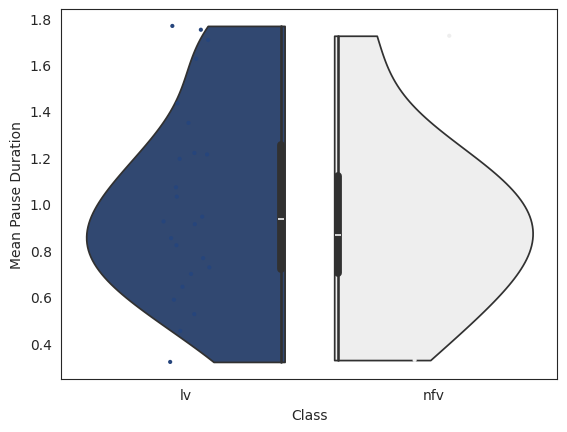

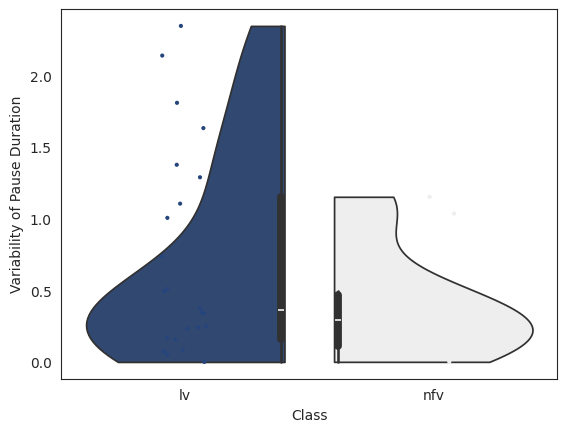

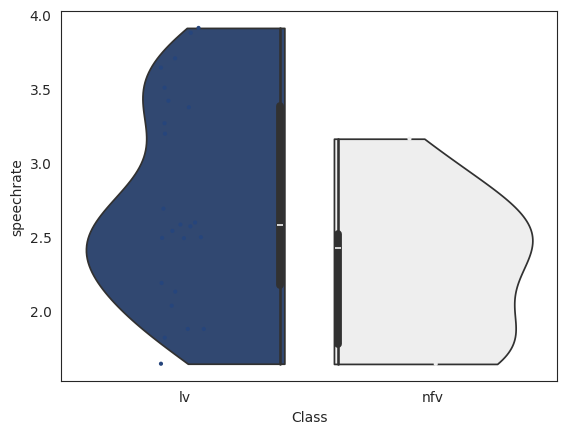

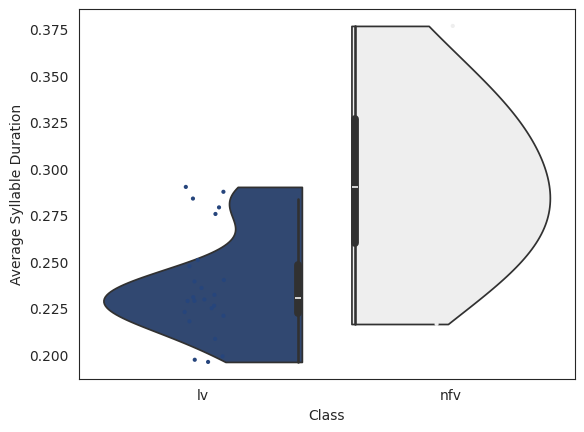

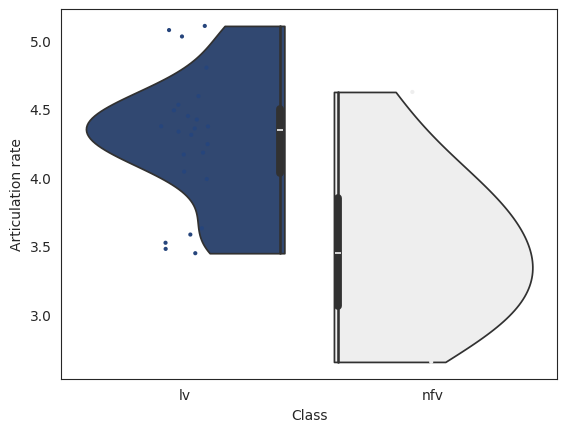

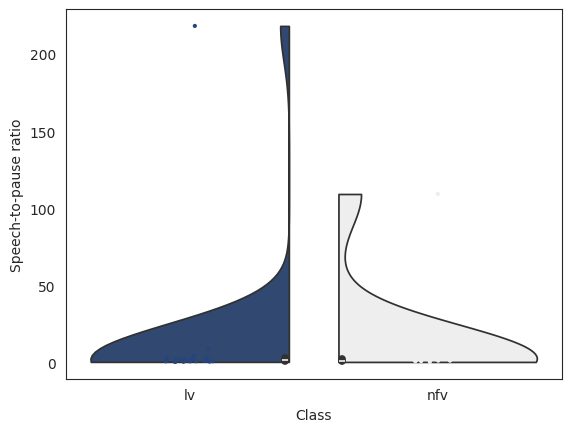

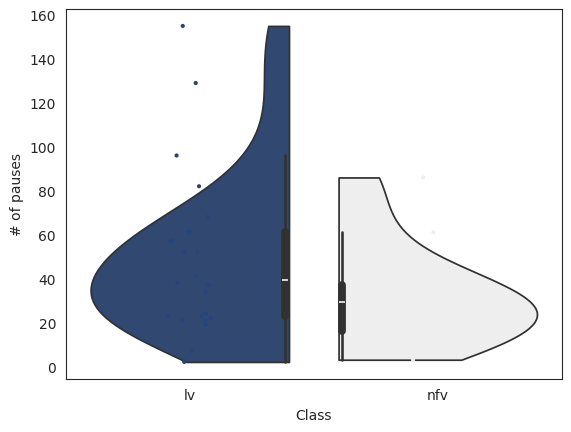

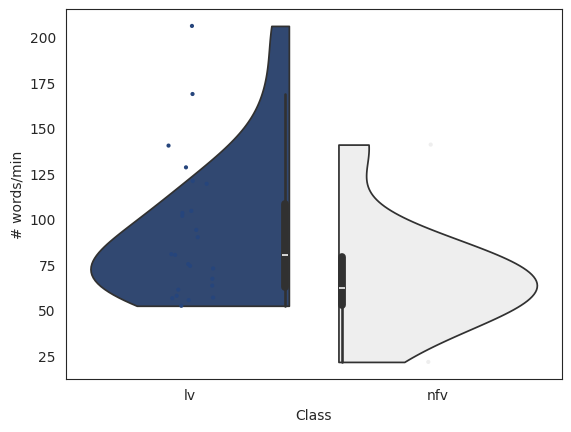

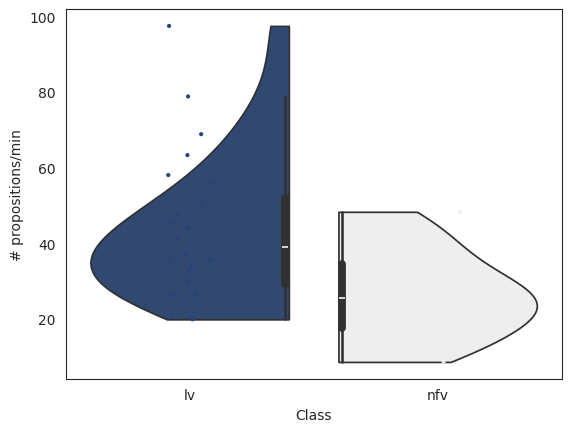

In [ ]:
for feature in temp_data_X.columns:
  if feature in ['Sample','Class']:
    continue
  plotOneVariable(feature)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

# suppress FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

def plot_multiple_violin_distributions_dots(df, feature_list, numPlotsPerRow=2):
    """
    Plots violin plots comparing the distribution of multiple features
    between two classes: 'nfv' (blue) and 'lv' (green),
    with individual data points shown as dots.

    Parameters:
    - df (pd.DataFrame): The dataframe containing the data.
    - feature_list (list of str): List of feature names to plot.
    """
    if 'Class' not in df.columns:
        raise ValueError("DataFrame must contain a 'Class' column.")

    # Filter out invalid features
    valid_features = [feat for feat in feature_list if feat in df.columns]
    invalid_features = [feat for feat in feature_list if feat not in df.columns]
    if invalid_features:
        print(f"Warning: These features were not found in the DataFrame and will be skipped: {invalid_features}")

    n = len(valid_features)
    if n == 0:
        raise ValueError("No valid features to plot.")

    class_order = ['nfv', 'lv']
    class_palette = {
        'nfv': 'purple',
        'lv': 'blue'
    }

    sns.set(style="whitegrid")

    # Determine layout
    cols = numPlotsPerRow
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    valid_features = [feat for feat in valid_features if feat not in ['Sample','Class']]

    for i, feature in enumerate(valid_features):
        ax = axes[i]

        # Violin plot
        sns.violinplot(
            data=df, x='Class', y=feature, ax=ax,
            order=class_order, palette=class_palette,
            inner="quartile", cut=0
        )

        # Add stripplot for datapoints
        sns.stripplot(
            data=df, x='Class', y=feature, ax=ax,
            order=class_order, dodge=True, color='black',
            alpha=0.6, size=4, jitter=True
        )
        ax.set_title(f'{feature}')
        ax.set_xlabel('Class')
        ax.set_ylabel('')

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


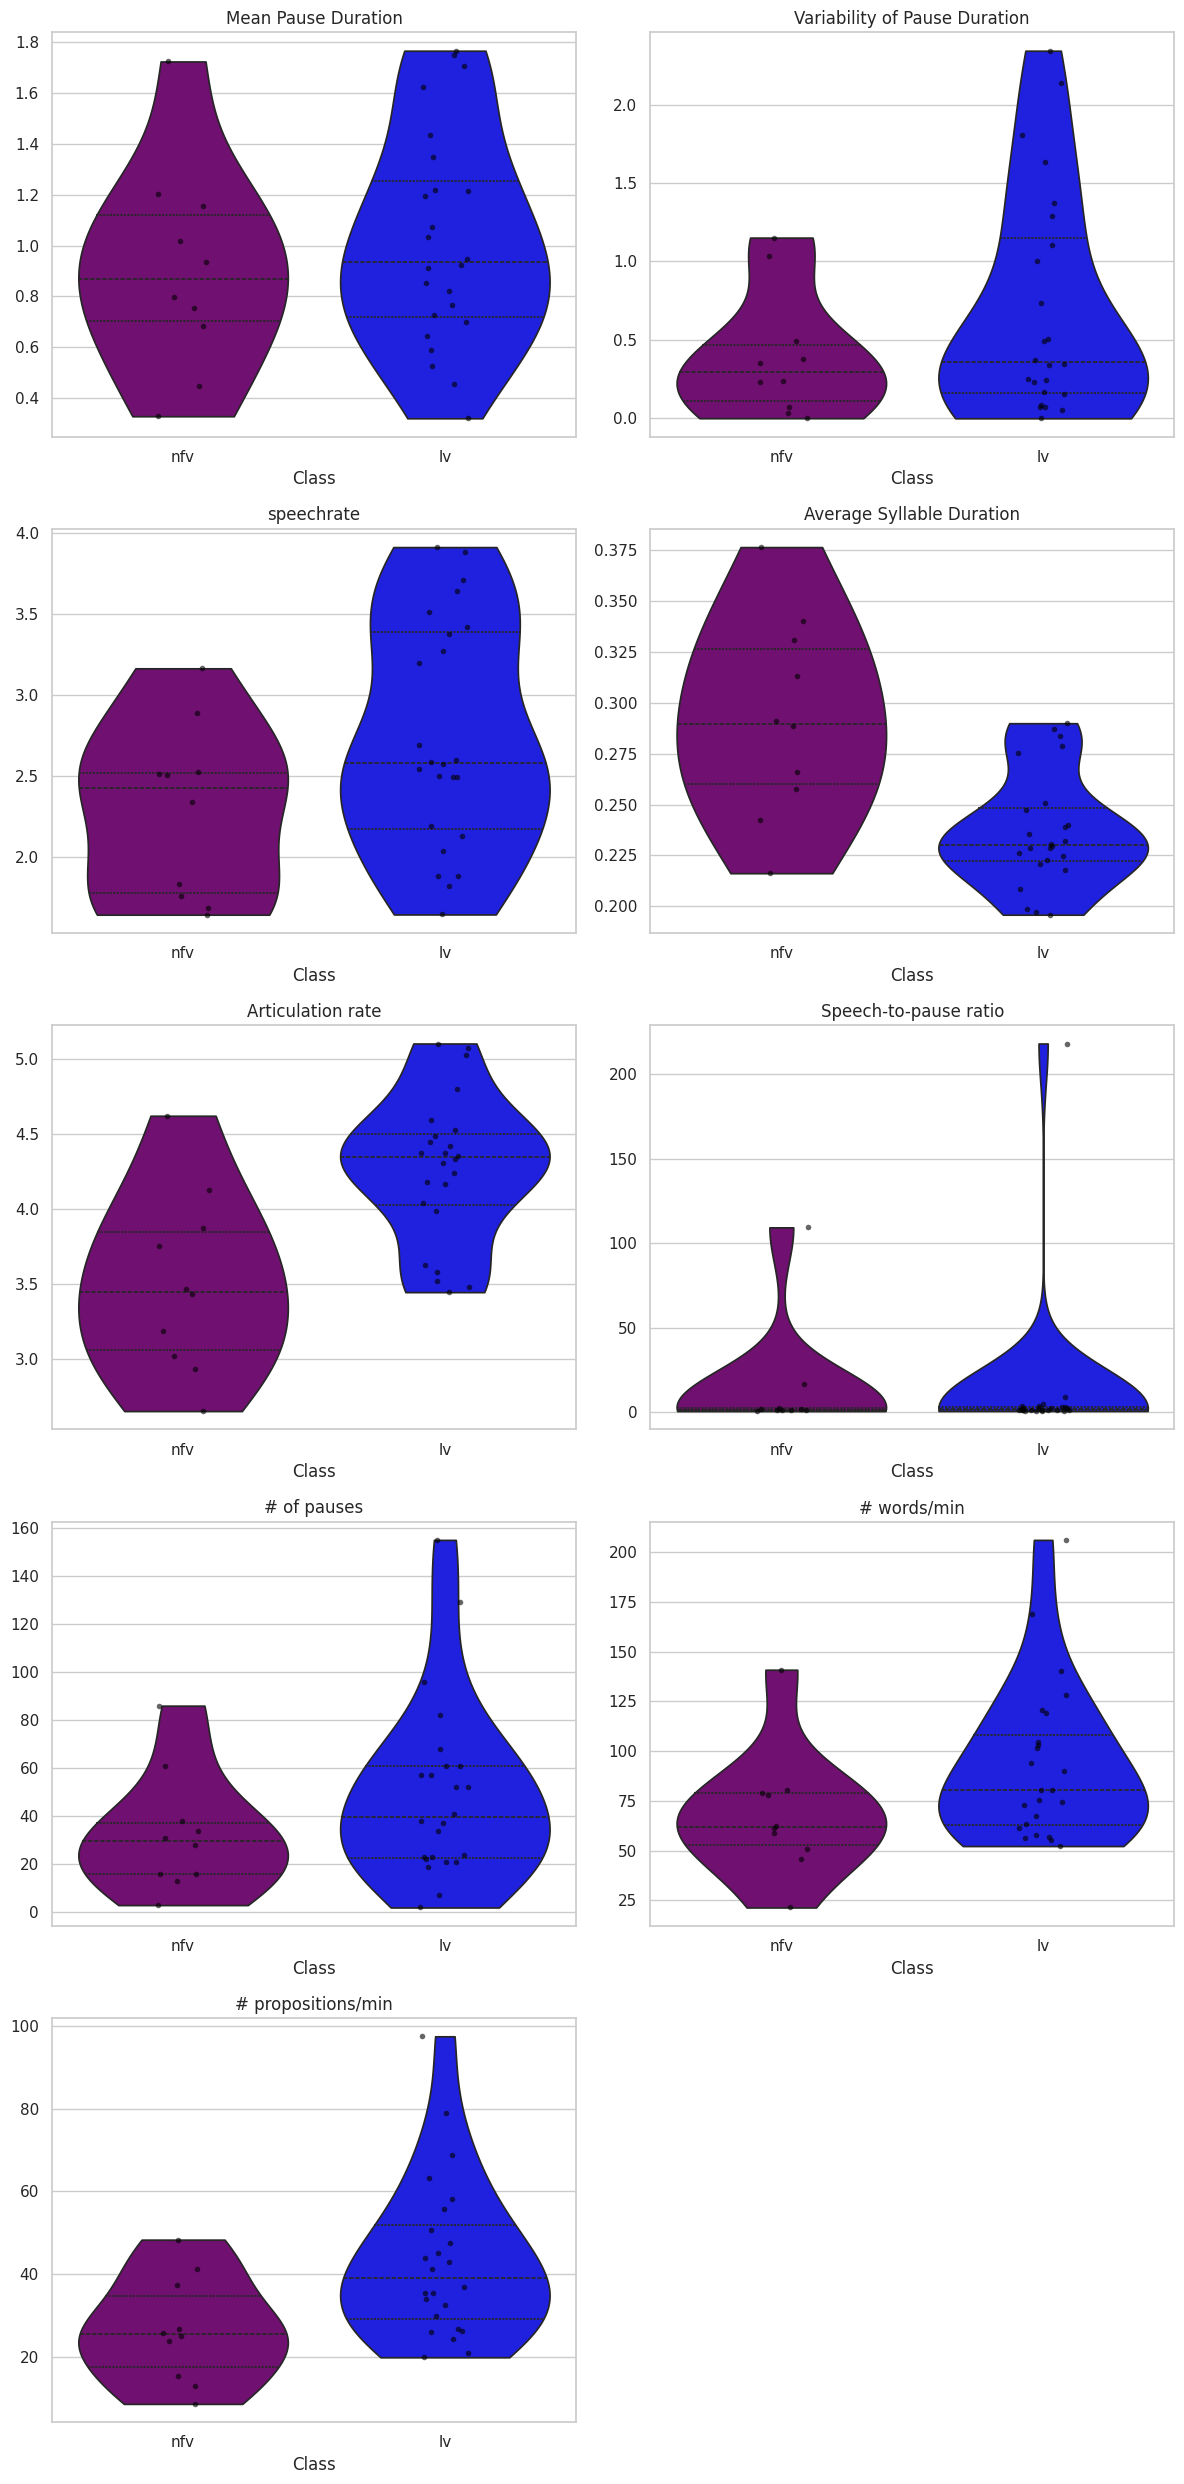

In [ ]:
plot_multiple_violin_distributions_dots(temp_data_X, temp_data_X.columns, numPlotsPerRow=2)

###Min, max, mean, SD

In [ ]:
import pandas as pd

# Example: assume your DataFrame is called df
means = temp_data_X.mean(numeric_only=True)
stds = temp_data_X.std(numeric_only=True)
mins = temp_data_X.min(numeric_only=True)
maxs = temp_data_X.max(numeric_only=True)

# Combine into a single summary table
summary = pd.DataFrame({
    'Mean': means,
    'Standard Deviation': stds,
    'Min': mins,
    'Max': maxs
})

print(summary)

                                    Mean  Standard Deviation        Min  \
Mean Pause Duration             0.988057            0.412248   0.320000   
Variability of Pause Duration   0.611501            0.645368   0.000000   
speechrate                      2.611299            0.683734   1.641919   
Average Syllable Duration       0.253337            0.043053   0.195858   
Articulation rate               4.048015            0.621386   2.655048   
Speech-to-pause ratio          12.015667           40.875027   0.687459   
# of pauses                    44.352941           34.337789   2.000000   
# words/min                    85.581974           38.107910  21.416334   
# propositions/min             38.411165           19.085226   8.566533   

                                      Max  
Mean Pause Duration              1.766800  
Variability of Pause Duration    2.344119  
speechrate                       3.911343  
Average Syllable Duration        0.376641  
Articulation rate            

In [ ]:
summary.to_csv('DL_SpeechTiming.csv')

#ML Methods

Extra functionalities: see predicted time needed, each fold's best model

In [ ]:
list(data_Y)

['lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'nfv',
 'nfv',
 'nfv',
 'nfv',
 'nfv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'lv',
 'nfv',
 'lv',
 'nfv',
 'nfv',
 'nfv',
 'nfv']

In [ ]:
data_Y = [0 if y == 'nfv' else 1 for y in list(data_Y)]
print(data_Y)

[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

In [ ]:
def looNCVWithTiming(param_grid, clf):
  import numpy as np
  import pandas as pd
  from sklearn.model_selection import GridSearchCV, LeaveOneOut
  from sklearn.inspection import permutation_importance
  from sklearn.metrics import accuracy_score
  from tqdm import tqdm
  import time
  from sklearn.model_selection import cross_val_predict
  from sklearn.metrics import confusion_matrix
  from sklearn.metrics import classification_report
  X = data_X
  y = np.array(data_Y)

# --- Storage ---
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()
  numInnerFolds = 5

  print("Running nested LOO CV")
  from sklearn.preprocessing import StandardScaler
  from sklearn.decomposition import PCA
  from sklearn.neural_network import MLPClassifier
  from sklearn.pipeline import Pipeline

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    start_time = time.time()
    #scaler = StandardScaler()
    grid_search = GridSearchCV(clf, param_grid, cv=numInnerFolds, scoring='f1_macro',n_jobs=-1) #n_jobs ensures parrallelization speedup
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print(f"Best params for outer fold {test_idx}: {grid_search.best_params_}")

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1] #1 means P(aphasia)
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: cv loop lasted {elapsed:.2f} seconds")

# --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=['nfvPPA', 'lvPPA']))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)

  from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
  import numpy as np
  import matplotlib.pyplot as plt
  fpr, tpr, thresholds = roc_curve(data_Y, test_preds_probs)
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.legend(loc='lower right')
  plt.grid()
  plt.show()

# Post-Hoc Threshold Tuning
  optimal_idx = np.argmax(tpr - fpr)
  optimal_threshold = thresholds[optimal_idx]
  print(f"Optimal Threshold: {optimal_threshold}")

# Apply the optimal threshold
  adjusted_predictions = (test_preds_probs >= optimal_threshold).astype(int)
  print("Predictions using adjusted threshold:", adjusted_predictions)

# Evaluate the new predictions
  print("Confusion Matrix with Adjusted Threshold:")
  print(confusion_matrix(data_Y, adjusted_predictions))
  print("Classification Report with Adjusted Threshold:")
  print(classification_report(data_Y, adjusted_predictions, target_names=['nfvPPA', 'lvPPA']))

  print("Prettier confusion matrix for adjusted threshold:")
  generateBetterConfusionMatrix(test_true, adjusted_predictions)
  print("Prettier confusion matrix for default threshold:")
  generateBetterConfusionMatrix(test_true, test_preds)

In [ ]:
def generateBetterConfusionMatrix(test_true,test_preds):
  import matplotlib.pyplot as plt
  import numpy as np
  from sklearn.metrics import confusion_matrix

# Compute confusion matrix and normalized version
  cm = confusion_matrix(test_true, test_preds)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  row_totals = cm.sum(axis=1)


  plt.rcParams.update({
    'font.size': 14,          # base font size
    'axes.labelsize': 16,     # x/y label size
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
  })


# Plot setup
  fig, ax = plt.subplots()
  im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)  # Use 'Blues'
  cbar = plt.colorbar(im, ax=ax)

# Axis setup
  class_names = ['nfvPPA', 'lvPPA']
  ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True diagnosis',
       xlabel='Predicted diagnosis')
  plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        total = row_totals[i]
        percent = cm_normalized[i, j] * 100

        # Get brightness to set text color (luminance rule of thumb)
        brightness = im.cmap(cm_normalized[i, j])[:3]  # RGB
        luminance = 0.299 * brightness[0] + 0.587 * brightness[1] + 0.114 * brightness[2]
        text_color = 'black' if luminance > 0.5 else 'white'

        ax.text(j, i, f'{percent:.0f}% ({count}/{total})',
                ha='center', va='center', color=text_color, fontsize=14)

  plt.tight_layout()
  plt.show()


#Decision Tree (64%)

In [ ]:
decision_tree_param_grid = {
    "class_weight": ["balanced", None],
    "criterion": ["gini"],
    "max_depth": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:06<03:42,  6.73s/it]

Best params for outer fold [0]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None}
Test idx 0: cv loop lasted 6.72 seconds


Outer folds:   6%|▌         | 2/34 [00:08<02:06,  3.95s/it]

Best params for outer fold [1]: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None}
Test idx 1: cv loop lasted 1.99 seconds


...

Best params for outer fold [31]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt'}
Test idx 31: cv loop lasted 0.57 seconds


Outer folds:  97%|█████████▋| 33/34 [00:32<00:00,  1.67it/s]

Best params for outer fold [32]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt'}
Test idx 32: cv loop lasted 0.62 seconds


Outer folds: 100%|██████████| 34/34 [00:32<00:00,  1.03it/s]

Best params for outer fold [33]: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt'}
Test idx 33: cv loop lasted 0.59 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.33      0.50      0.40        10
       lvPPA       0.74      0.58      0.65        24

    accuracy                           0.56        34
   macro avg       0.54      0.54      0.53        34
weighted avg       0.62      0.56      0.58        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
Ev

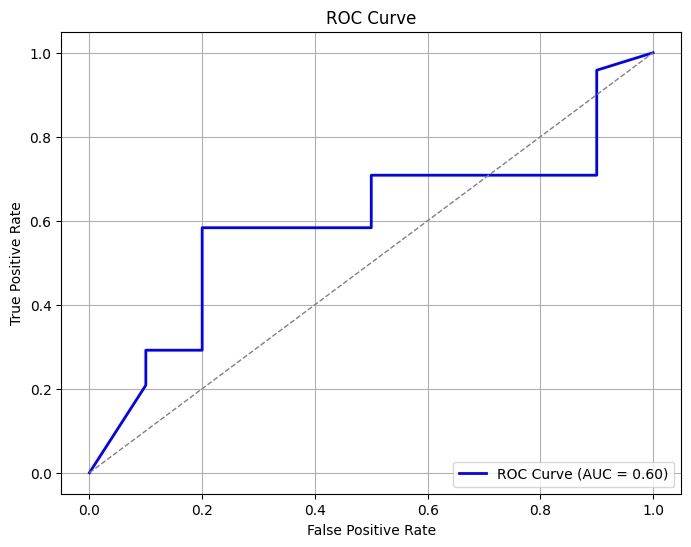

Optimal Threshold: 0.8743169398907104
Predictions using adjusted threshold: [1 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 0 0]
Confusion Matrix with Adjusted Threshold:
[[ 8  2]
 [10 14]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.44      0.80      0.57        10
       lvPPA       0.88      0.58      0.70        24

    accuracy                           0.65        34
   macro avg       0.66      0.69      0.64        34
weighted avg       0.75      0.65      0.66        34

Prettier confusion matrix for adjusted threshold:


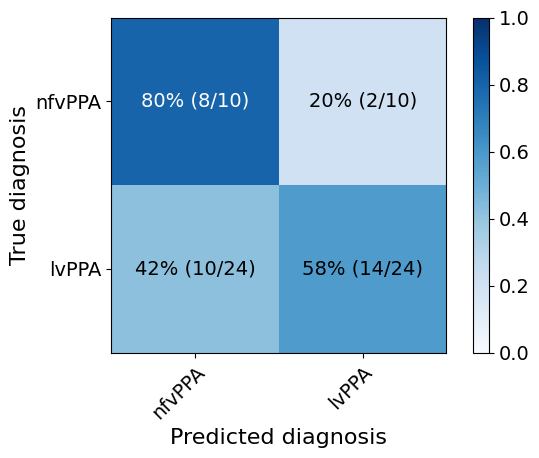

Prettier confusion matrix for default threshold:


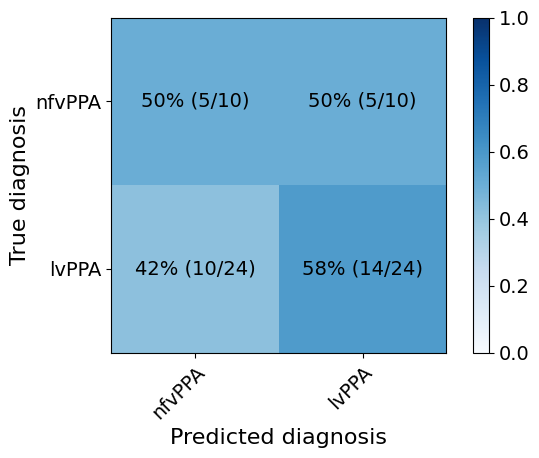

In [ ]:
looNCVWithTiming(param_grid=decision_tree_param_grid, clf=DecisionTreeClassifier(random_state=0))

#Gradient Boosting (67%)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:03<02:03,  3.74s/it]

Best params for outer fold [0]: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 25}
Test idx 0: cv loop lasted 3.74 seconds


Outer folds:   6%|▌         | 2/34 [00:07<01:57,  3.68s/it]

Best params for outer fold [1]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 25}
Test idx 1: cv loop lasted 3.63 seconds


...

Best params for outer fold [31]: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 25}
Test idx 31: cv loop lasted 2.93 seconds


Outer folds:  97%|█████████▋| 33/34 [01:51<00:03,  3.21s/it]

Best params for outer fold [32]: {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 25}
Test idx 32: cv loop lasted 3.17 seconds


Outer folds: 100%|██████████| 34/34 [01:55<00:00,  3.40s/it]

Best params for outer fold [33]: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 25}
Test idx 33: cv loop lasted 4.16 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.56      0.50      0.53        10
       lvPPA       0.80      0.83      0.82        24

    accuracy                           0.74        34
   macro avg       0.68      0.67      0.67        34
weighted avg       0.73      0.74      0.73        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
Evaluation true: [np.int64(1), n

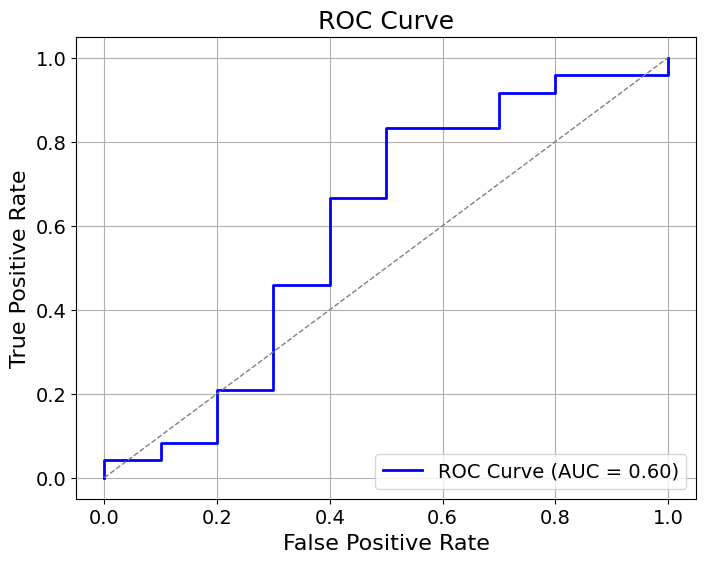

Optimal Threshold: 0.5538672497317406
Predictions using adjusted threshold: [1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 0]
Confusion Matrix with Adjusted Threshold:
[[ 5  5]
 [ 4 20]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.56      0.50      0.53        10
       lvPPA       0.80      0.83      0.82        24

    accuracy                           0.74        34
   macro avg       0.68      0.67      0.67        34
weighted avg       0.73      0.74      0.73        34

Prettier confusion matrix for adjusted threshold:


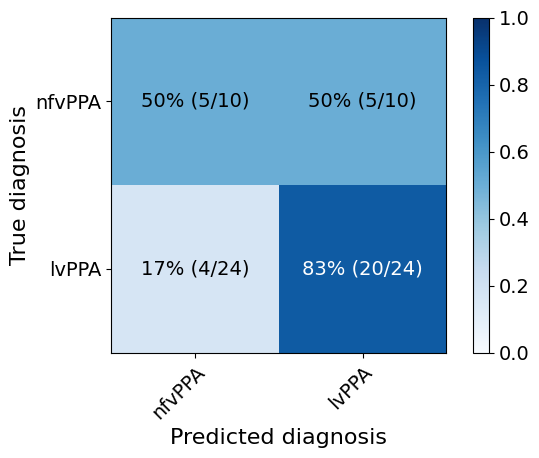

Prettier confusion matrix for default threshold:


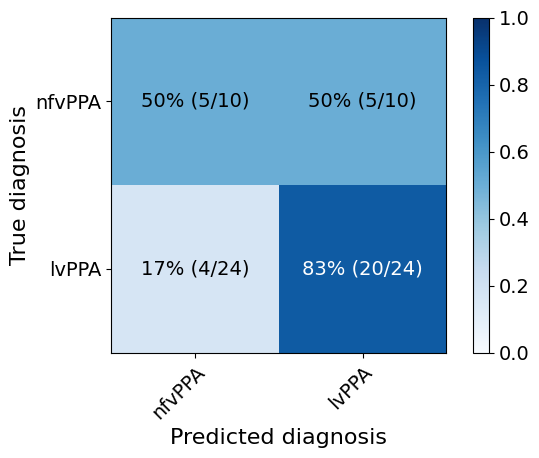

In [ ]:
gbcParamGrid = {
    "n_estimators": [25, 50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2]
}
looNCVWithTiming(param_grid=gbcParamGrid, clf=GradientBoostingClassifier(random_state=0))

#SVM (70%, AUC=76)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.decomposition import PCA
reducer = PCA(random_state=0)
from sklearn.svm import SVC
clf = SVC(random_state=0,class_weight='balanced',probability=True)
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('pca', reducer), ('SVM', clf)])
linear_svm_grid = {
    "SVM__kernel": ["linear"],
    "SVM__C": [0.01, 0.1, 1.0],
    "SVM__class_weight": ["balanced", None]
}
rbf_svm_grid = {
    "pca__n_components": [1,2,3],
    "SVM__kernel": ["rbf"],
    "SVM__C": [0.1, 1.0],
    "SVM__gamma": ["scale"],
    "SVM__class_weight": ["balanced", None]
}
svmParamGrid = [linear_svm_grid, rbf_svm_grid]

Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:00<00:30,  1.07it/s]

Best params for outer fold [0]: {'SVM__C': 0.1, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 0: cv loop lasted 0.94 seconds


Outer folds:   6%|▌         | 2/34 [00:01<00:29,  1.09it/s]

Best params for outer fold [1]: {'SVM__C': 0.1, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 1: cv loop lasted 0.90 seconds


...

Best params for outer fold [31]: {'SVM__C': 0.01, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 31: cv loop lasted 0.90 seconds


Outer folds:  97%|█████████▋| 33/34 [00:33<00:00,  1.06it/s]

Best params for outer fold [32]: {'SVM__C': 0.1, 'SVM__class_weight': 'balanced', 'SVM__kernel': 'linear'}
Test idx 32: cv loop lasted 0.93 seconds


Outer folds: 100%|██████████| 34/34 [00:34<00:00,  1.01s/it]

Best params for outer fold [33]: {'SVM__C': 1.0, 'SVM__class_weight': 'balanced', 'SVM__gamma': 'scale', 'SVM__kernel': 'rbf', 'pca__n_components': 2}
Test idx 33: cv loop lasted 0.97 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      0.50      0.50        10
       lvPPA       0.79      0.79      0.79        24

    accuracy                           0.71        34
   macro avg       0.65      0.65      0.65        34
weighted avg       0.71      0.71      0.71        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), 

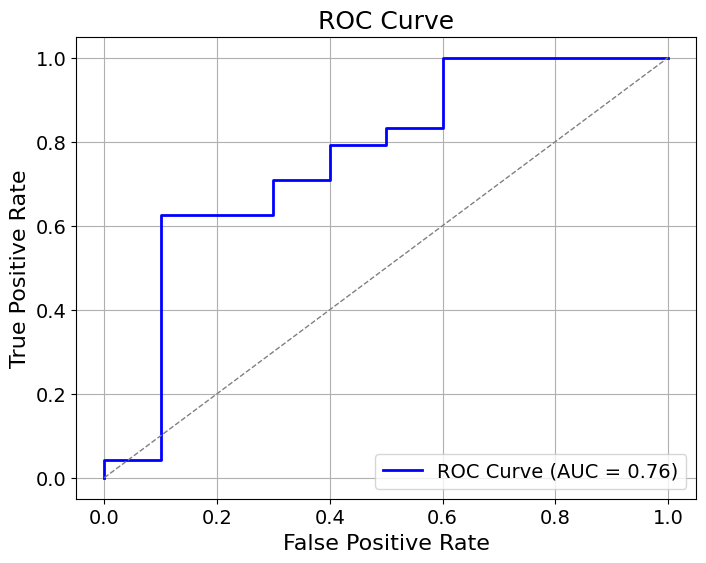

Optimal Threshold: 0.7895766852276955
Predictions using adjusted threshold: [1 0 1 0 1 0 0 0 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0 0 0 0 0 0]
Confusion Matrix with Adjusted Threshold:
[[ 9  1]
 [ 9 15]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      0.90      0.64        10
       lvPPA       0.94      0.62      0.75        24

    accuracy                           0.71        34
   macro avg       0.72      0.76      0.70        34
weighted avg       0.81      0.71      0.72        34

Prettier confusion matrix for adjusted threshold:


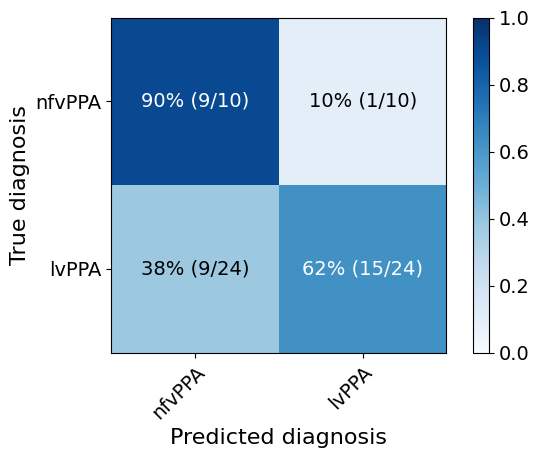

Prettier confusion matrix for default threshold:


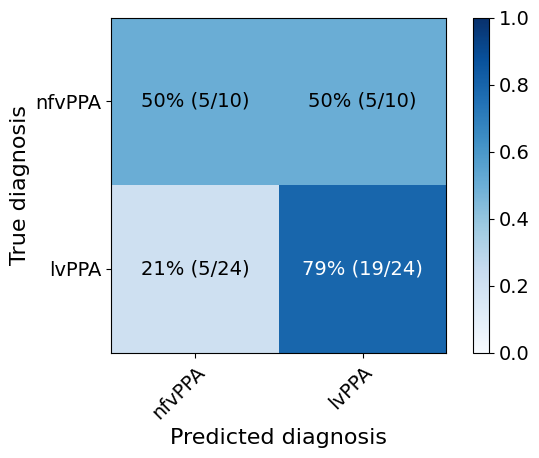

In [ ]:
looNCVWithTiming(param_grid=svmParamGrid, clf=pipe)

#SNN (70%, AUC=81)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(
    random_state=0,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10
)

In [ ]:
snn_param_grid = {
    "MLP__hidden_layer_sizes": [
        (5,), #minimal nonlinearity
        (10,), #moderate flexibility
        (15,) #Hidden units ≲ number of features
    ],
    "MLP__activation": [
        "tanh", #Zero-centered, stable for small datasets
        "relu" #default activation function
    ],
    "MLP__alpha": [
        1e-4,
        1e-3,
        1e-2
    ],
    "MLP__solver": [
        "adam"
    ]
}


Running nested LOO CV


Outer folds:   3%|▎         | 1/34 [00:02<01:28,  2.69s/it]

Best params for outer fold [0]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (15,), 'MLP__solver': 'adam'}
Test idx 0: cv loop lasted 2.69 seconds


Outer folds:   6%|▌         | 2/34 [00:04<01:18,  2.46s/it]

Best params for outer fold [1]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (15,), 'MLP__solver': 'adam'}
Test idx 1: cv loop lasted 2.29 seconds


...

Best params for outer fold [31]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (15,), 'MLP__solver': 'adam'}
Test idx 31: cv loop lasted 5.75 seconds


Outer folds:  97%|█████████▋| 33/34 [01:15<00:03,  3.47s/it]

Best params for outer fold [32]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (15,), 'MLP__solver': 'adam'}
Test idx 32: cv loop lasted 3.70 seconds


Outer folds: 100%|██████████| 34/34 [01:18<00:00,  2.32s/it]

Best params for outer fold [33]: {'MLP__activation': 'relu', 'MLP__alpha': 0.0001, 'MLP__hidden_layer_sizes': (15,), 'MLP__solver': 'adam'}
Test idx 33: cv loop lasted 3.35 seconds
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.80      0.40      0.53        10
       lvPPA       0.79      0.96      0.87        24

    accuracy                           0.79        34
   macro avg       0.80      0.68      0.70        34
weighted avg       0.80      0.79      0.77        34

Evaluation preds: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)

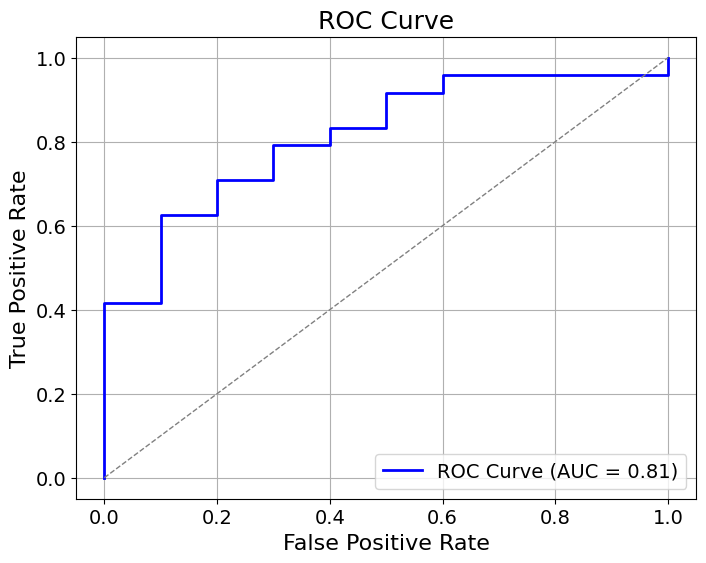

Optimal Threshold: 0.7100961413889513
Predictions using adjusted threshold: [1 1 1 1 1 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 0]
Confusion Matrix with Adjusted Threshold:
[[ 9  1]
 [ 9 15]]
Classification Report with Adjusted Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.50      0.90      0.64        10
       lvPPA       0.94      0.62      0.75        24

    accuracy                           0.71        34
   macro avg       0.72      0.76      0.70        34
weighted avg       0.81      0.71      0.72        34

Prettier confusion matrix for adjusted threshold:


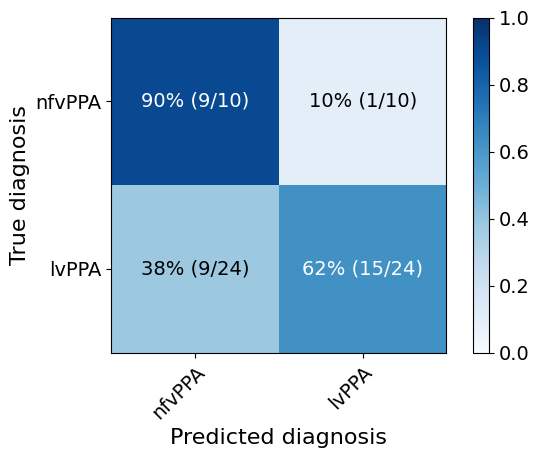

Prettier confusion matrix for default threshold:


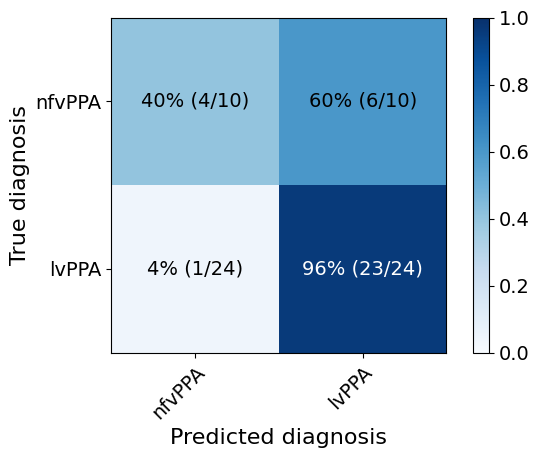

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('MLP', clf)])
looNCVWithTiming(param_grid=snn_param_grid, clf=pipe)

#Most Freq Baseline (41%)



In [ ]:
#import DummyClassifier from sklearn
from sklearn.dummy import DummyClassifier
#import cross_val_predict from sklearn
from sklearn.model_selection import cross_val_predict

In [ ]:
mostfreq_baseline = DummyClassifier(strategy="most_frequent",random_state=99)
predicted = cross_val_predict(mostfreq_baseline, data_X, data_Y, cv=5)
print(predicted)
print(confusion_matrix(data_Y, predicted))
print(classification_report(data_Y, predicted,target_names=['Non-Aphasia','Aphasia']))
print(accuracy_score(data_Y, predicted))

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[ 0 10]
 [ 0 24]]
              precision    recall  f1-score   support

 Non-Aphasia       0.00      0.00      0.00        10
     Aphasia       0.71      1.00      0.83        24

    accuracy                           0.71        34
   macro avg       0.35      0.50      0.41        34
weighted avg       0.50      0.71      0.58        34

0.7058823529411765


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Permutation analysis

##General code

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import LeaveOneOut

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

def looNCVPermutationImportance(clf, param_grid, threshold, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA']):
  X = data_X
  y = np.array(data_Y)
  perm_importances_per_fold = []
  test_preds = []
  test_preds_probs = []
  test_true = []

  loo = LeaveOneOut()

  print("Running nested LOO CV with permutation importance...")

  for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc="Outer folds"):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    #print(train_idx, test_idx)
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV: Grid search for hyperparameters
    gridSearch = GridSearchCV(clf, param_grid, cv=5, scoring=criterion)
    gridSearch.fit(X_train, y_train)
    best_model = gridSearch.best_estimator_

    # Save prediction
    y_pred = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]
    test_preds.extend(y_pred)
    test_preds_probs.extend(y_pred_prob)
    test_true.extend(y_test)

    # Permutation importance (with timing)
    start_time = time.time()
    result = permutation_importance(
        best_model,
        X_train,
        y_train,
        n_repeats=n_repeats,
        random_state=42,
        scoring=criterion,
        n_jobs=-1
    )
    elapsed = time.time() - start_time
    print(f"Test idx {test_idx[0]}: Permutation importance took {elapsed:.2f} seconds")

    perm_importances_per_fold.append(result.importances_mean)

# --- Aggregate permutation importances ---
  perm_importances_per_fold = np.array(perm_importances_per_fold)
  feature_names = X.columns
  mean_importances = np.mean(perm_importances_per_fold, axis=0)
  median_importances = np.median(perm_importances_per_fold, axis=0)

# --- Report ---
  importances_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importances,
    'median_importance': median_importances
  }).sort_values(by='mean_importance', ascending=False)

  print("\nPermutation Importances Across LOO CV:")
  #print(importances_df)

  # --- Final model performance ---
  print("Classification Report with Default Threshold:")
  print(classification_report(test_true, test_preds, target_names=class_names))

  print("Mean feature importance:", list(zip(importances_df['feature'], importances_df['mean_importance'])))
  print("Median feature importance:", list(zip(importances_df['feature'], importances_df['median_importance'])))
  print("Evaluation preds:", test_preds)
  print("Evaluation true:", test_true)
  print("Evaluation pred probs:", test_preds_probs)
  print("Tuned threshold:", threshold)
  adjusted_test_preds = [1 if x >= threshold else 0 for x in test_preds_probs]
  print("Evaluation preds with tuned threshold:", adjusted_test_preds)
  print("Classification Report with tuned Threshold:")
  print(classification_report(test_true, adjusted_test_preds, target_names=class_names))
  #return importances_df

##run

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(
    random_state=0,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10
)
snn_param_grid = {
    "MLP__hidden_layer_sizes": [
        (5,), #minimal nonlinearity
        (10,), #moderate flexibility
        (15,) #Hidden units ≲ number of features
    ],
    "MLP__activation": [
        "tanh", #Zero-centered, stable for small datasets
        "relu" #default activation function
    ],
    "MLP__alpha": [
        1e-4,
        1e-3,
        1e-2
    ],
    "MLP__solver": [
        "adam"
    ]
}
from sklearn.pipeline import Pipeline
pipe = Pipeline(steps=[('scaler', scaler), ('MLP', clf)])
threshold=0.7100961413889513
looNCVPermutationImportance(clf=pipe, param_grid=snn_param_grid, threshold=0.7100961413889513, n_repeats=10000, criterion='f1_macro', class_names=['nfvPPA','lvPPA'])

Running nested LOO CV with permutation importance...


Outer folds:   3%|▎         | 1/34 [05:52<3:13:47, 352.35s/it]

Test idx 0: Permutation importance took 349.95 seconds


Outer folds:   6%|▌         | 2/34 [11:42<3:07:14, 351.06s/it]

Test idx 1: Permutation importance took 348.04 seconds


...

Test idx 31: Permutation importance took 347.23 seconds


Outer folds:  97%|█████████▋| 33/34 [3:13:05<05:48, 348.71s/it]

Test idx 32: Permutation importance took 343.54 seconds


Outer folds: 100%|██████████| 34/34 [3:18:54<00:00, 351.00s/it]

Test idx 33: Permutation importance took 346.47 seconds

Permutation Importances Across LOO CV:
Classification Report with Default Threshold:
              precision    recall  f1-score   support

      nfvPPA       0.80      0.40      0.53        10
       lvPPA       0.79      0.96      0.87        24

    accuracy                           0.79        34
   macro avg       0.80      0.68      0.70        34
weighted avg       0.80      0.79      0.77        34

Mean feature importance: [('Articulation rate', 0.17919310506508856), ('# of pauses', 0.10845327300687169), ('speechrate', 0.10737521859582552), ('Variability of Pause Duration', 0.08570994314040208), ('Mean Pause Duration', 0.06031011331701698), ('Average Syllable Duration', 0.05394623304796555), ('# words/min', 0.013663569466337021), ('# propositions/min', 0.0010638803101182678), ('Speech-to-pause ratio', -0.019361615808196654)]
Median feature importance: [('Articulation rate', 0.17440644606386085), ('# of pauses', 0.102554